# Блок 7. Основы искусственного интеллекта и машинного обучения
# Занятие 4. Практика регрессии на датасете недвижимости

## Цель занятия

На прошлом занятии мы изучили линейную регрессию.

Сегодня будем работать как настоящий аналитик данных:

- использовать больше признаков;
- сравнивать качество модели;
- анализировать важность признаков;
- интерпретировать ошибки;
- строить графики;
- формировать бизнес-отчёт.

## Датасет

California Housing

https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv

## Связь с дипломом

Это практически готовый шаблон для дипломов:

- недвижимость;
- продажи;
- финансы;
- медицина;
- спорт.


Сначала изучите SOLVED ноутбук, затем выполните TODO самостоятельно.

## Ячейка 1. Загрузка датасета

### Алгоритм
Загружаем реальные данные недвижимости.

In [92]:
import pandas as pd
from IPython.display import display

url = "../../data/daily_table.csv"
df: pd.DataFrame = pd.read_csv(url)

print(df.shape)
assert len(df) > 1000


(5249, 17)


## Ячейка 2. Изучение признаков

### Алгоритм
Смотрим структуру данных.

In [93]:

feature_cols = ['energy_kcal', 'protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g',
                'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g']
target_col = "weight_diff"

df[target_col] = df["weight"] - df["start_weight"]

display(df.head())
print(df.columns.tolist())

assert "weight" in df.columns

,id,date,meals,products,start_weight,weight,energy_kcal,protein_g,fat_g,carbohydrates_g,fiber_g,sugars_g,saturated_fat_g,cholesterol_mg,sodium_mg,potassium_mg,water_g,weight_diff
0,0060b6899180e194092d60a0e50aeea1,2019/2/22,3,7,69.0,68.3,1418.0,65.12,37.88,210.64,19.5,32.23,5.131,44.0,1738.0,1032.0,299.40,-0.7
1,0060b6899180e194092d60a0e50aeea1,2019/2/23,3,12,68.3,68.8,2301.0,63.65,92.39,309.36,24.8,66.61,13.076,82.0,3655.0,1925.0,618.95,0.5
2,0060b6899180e194092d60a0e50aeea1,2019/2/24,3,13,68.8,68.2,2684.0,87.26,69.32,434.98,28.1,130.80,17.871,161.0,7483.0,2572.0,667.44,-0.6
3,0060b6899180e194092d60a0e50aeea1,2019/2/25,3,6,68.2,68.2,1387.0,46.61,66.30,163.96,11.6,3.06,24.028,80.0,1516.0,2041.0,312.80,0.0
4,0060b6899180e194092d60a0e50aeea1,2019/2/26,3,6,68.2,68.2,1466.0,25.95,78.55,174.22,10.7,48.69,21.807,6.0,2094.0,986.0,312.31,0.0


['id', 'date', 'meals', 'products', 'start_weight', 'weight', 'energy_kcal', 'protein_g', 'fat_g', 'carbohydrates_g', 'fiber_g', 'sugars_g', 'saturated_fat_g', 'cholesterol_mg', 'sodium_mg', 'potassium_mg', 'water_g', 'weight_diff']


## Ячейка 3. Подготовка данных

### Алгоритм
Выбираем больше признаков.

In [94]:
df = df.dropna(subset=[target_col])

df[feature_cols] = df[feature_cols].fillna(0, inplace=False)
X = df[feature_cols]
y = df[target_col]

print(X.shape)
assert X.shape[1] == 11


(5249, 11)


## Ячейка 4. Разделение данных

### Алгоритм
Train/Test Split.

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(len(X_train) / len(X_test))
assert abs(len(X_train) / len(X_test) - 4) < 1e-2

3.999047619047619


## Ячейка 5. Масштабирование

### Алгоритм
Используем StandardScaler.

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

assert X_train_scaled.shape[1] == 11

## Ячейка 6. Обучение модели

### Алгоритм
Строим LinearRegression.

In [97]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

assert model is not None

## Ячейка 7. Важность признаков

### Алгоритм
Анализируем коэффициенты.

In [98]:
importance = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

importance = importance.sort_values(by="coefficient", ascending=False)

display(importance)

assert len(importance) == len(X.columns)

,feature,coefficient
0,energy_kcal,0.280269
7,cholesterol_mg,0.017878
6,saturated_fat_g,0.012978
4,fiber_g,0.007811
10,water_g,0.004827
8,sodium_mg,-0.000982
5,sugars_g,-0.013092
9,potassium_mg,-0.023156
1,protein_g,-0.046418
3,carbohydrates_g,-0.126619


## Ячейка 8. Метрики качества

### Алгоритм
Считаем MAE RMSE R2.

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(mae, rmse, r2)

assert r2 > 0

0.30879648727945197 0.419791056725063 0.00469990154838984


## Ячейка 9. Визуализация

### Алгоритм
Строим графики качества.

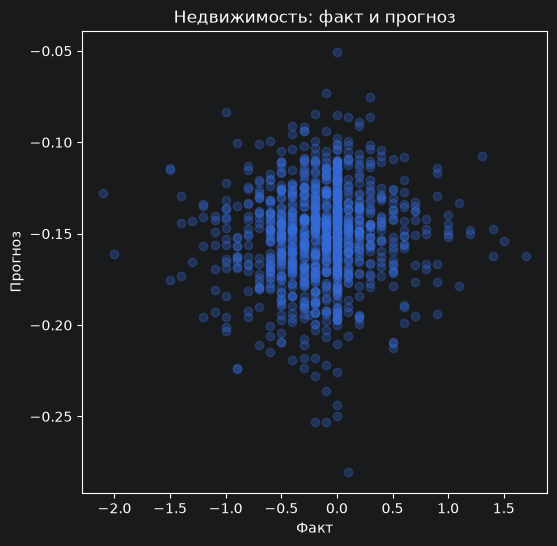

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test,pred,alpha=0.3)
plt.xlabel("Факт")
plt.ylabel("Прогноз")
plt.title("Недвижимость: факт и прогноз")
plt.show()

assert True


## Ячейка 10. Мини-проект

### Алгоритм
Формируем бизнес-отчет.

In [101]:
report={
"rows":len(df),
"features":len(X.columns),
"MAE":round(mae,2),
"RMSE":round(rmse,2),
"R2":round(r2,3),
"best_feature":importance.iloc[0]["feature"]
}

print(report)

assert report["features"]==11


{'rows': 5249, 'features': 11, 'MAE': 0.31, 'RMSE': np.float64(0.42), 'R2': 0.005, 'best_feature': 'energy_kcal'}
